# Retrieve DDL measurements

In [2]:
import matplotlib.pyplot as plt
import ddlpy

# enabling debug logging so we can see what happens in the background
import logging
logging.basicConfig()
logging.getLogger("ddlpy").setLevel(logging.DEBUG)

## Get a list of all known locations
The  method locations gets a list of all known measurement locations by sending a request. 

In [3]:
locations = ddlpy.locations()

INFO:ddlpy.ddlpy:Retrieving Waterwebservices catalog, this can take 30 seconds
DEBUG:ddlpy.ddlpy:Requesting at https://ddapi20-waterwebservices.rijkswaterstaat.nl/METADATASERVICES/OphalenCatalogus with request: {"CatalogusFilter": {"WaardeBewerkingsMethoden": true, "Typeringen": true, "Grootheden": true, "Parameters": true, "ProcesTypes": true, "Compartimenten": true, "Hoedanigheden": true, "Organen": true, "BioTaxon": true, "Eenheden": true, "Groeperingen": true}}


In [4]:
locations.to_json(r'locations.json', orient='records')

In [5]:
## also add code as a variable
locations['Code'] = locations.index
locations.head()

,Locatie_MessageID,Lat,Lon,Coordinatenstelsel,Naam,Omschrijving,Parameter_Wat_Omschrijving,ProcesType,Compartiment.Code,Compartiment.Omschrijving,...,BioTaxon.Omschrijving,Orgaan.Code,Orgaan.Omschrijving,Groepering.Code,Groepering.Omschrijving,Typering.Code,Typering.Omschrijving,WaardeBewerkingsMethode.Code,WaardeBewerkingsMethode.Omschrijving,Code
Code,,,,,,,,,,,,,,,,,,,,,
oosterhout,12201,51.630371,4.871365,ETRS89,Oosterhout,Oosterhout,(massa)Concentratie teflubenzuron in Oppervlak...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT,oosterhout
amelanderzeegat.2.2,7722,53.478028,5.570954,ETRS89,"Amelander zeegat, 2 .2",boei,Golffrequentie bij maximum v.h. variantiedicht...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT,amelanderzeegat.2.2
markengouwzee,993,52.460370,5.085581,ETRS89,Marken Gouwzee,Marken Gouwzee,(massa)Concentratie Chlorofyl fluorescentie in...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT,markengouwzee
renesse.badstrand.luieweg,5356,51.739668,3.750863,ETRS89,"Renesse, badstrand, Luieweg","Renesse, badstrand, Luieweg",Aantal in n,meting,NT,Niet van toepassing,...,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT,renesse.badstrand.luieweg
sluis,1213,51.309178,3.382084,ETRS89,Sluis,Sluis,(massa)Concentratie sulfaat in Oppervlaktewate...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT,sluis


## Validate
Check  if data is in the domain of the Netherlands. It also includes data of the North Sea.

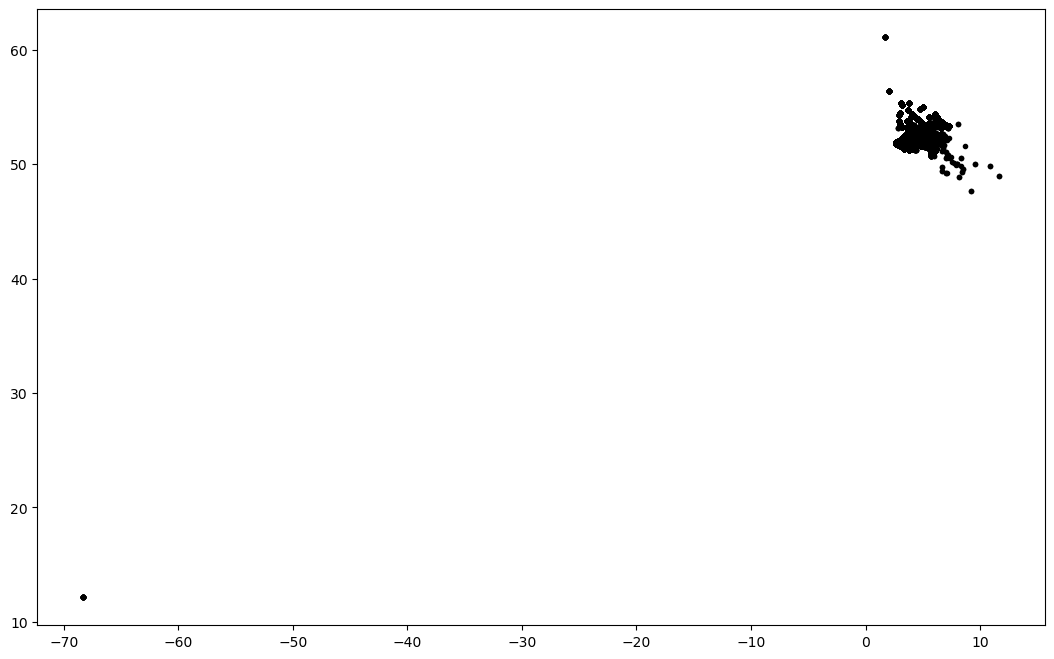

In [5]:
## Create a spatial plot
fig, ax = plt.subplots(figsize=(13, 8))
ax.plot(locations.Lon, locations.Lat, 'k.')

In [5]:
# CHECK See what the data in the east is.
# These is a reference river for water quality near Chernobyl. 
locations.sort_values('Lon',  ascending=False).head(n=5)

,Locatie_MessageID,Lat,Lon,Coordinatenstelsel,Naam,Omschrijving,Parameter_Wat_Omschrijving,ProcesType,Compartiment.Code,Compartiment.Omschrijving,...,BioTaxon.Code,BioTaxon.Omschrijving,Orgaan.Code,Orgaan.Omschrijving,Groepering.Code,Groepering.Omschrijving,Typering.Code,Typering.Omschrijving,WaardeBewerkingsMethode.Code,WaardeBewerkingsMethode.Omschrijving
Code,,,,,,,,,,,,,,,,,,,,,
riedenburg,9108,48.966667,11.666667,ETRS89,Riedenburg,Riedenburg,Waterhoogte in Oppervlaktewater t.o.v. Normaal...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT
riedenburg,9108,48.966667,11.666667,ETRS89,Riedenburg,Riedenburg,Waterhoogte in Oppervlaktewater t.o.v. plaatse...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT
bamberg,10201,49.883333,10.883333,ETRS89,Bamberg,Bamberg,Waterhoogte in Oppervlaktewater t.o.v. Normaal...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT
bamberg,10201,49.883333,10.883333,ETRS89,Bamberg,Bamberg,Waterhoogte in Oppervlaktewater t.o.v. plaatse...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT
steinbach,10205,49.999199,9.582227,ETRS89,Steinbach,Steinbach,Waterhoogte in Oppervlaktewater t.o.v. Normaal...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT


In [6]:
names = 'holland'
bool_stations = locations['Naam'].str.contains(names, case=False)
#bool_stations_skip = locations['Code'].str.contains('hoekvanholland', case=False)

bool_lat = locations['Lat'].between(52.0, 52.7)
bool_long = locations['Lon'].between(2.7, 4.6)

bool_procestype = locations['ProcesType'].isin(['meting']) # meting/astronomisch/verwachting
#bool_grootheid = locations['Grootheid.Code'].isin(['WATHTE']) # waterlevel (WATHTE)
bool_grootheid = locations['Grootheid.Omschrijving'].str.contains('richting', case=False)

bool_groepering = locations['Groepering.Code'].isin(['']) # timeseries ("") versus extremes (GETETM2/GETETMSL2/GETETBRKD2/GETETBRKDMSL2)
#bool_hoedanigheid = locations['Hoedanigheid.Code'].isin(['NAP']) # vertical reference (NAP/MSL)
#selected = locations.loc[bool_stations & bool_procestype & bool_grootheid & bool_groepering & bool_hoedanigheid]
bool_compartiment = locations['Compartiment.Code'].isin(['OW'])
#selected = locations.loc[bool_stations & ~bool_stations_skip & bool_lat & bool_long & bool_grootheid & bool_procestype & bool_groepering & bool_compartiment ]
selected = locations.loc[bool_stations  & bool_lat & bool_long & bool_grootheid & bool_procestype & bool_groepering & bool_compartiment ]

selected

,Locatie_MessageID,Lat,Lon,Coordinatenstelsel,Naam,Omschrijving,Parameter_Wat_Omschrijving,ProcesType,Compartiment.Code,Compartiment.Omschrijving,...,BioTaxon.Omschrijving,Orgaan.Code,Orgaan.Omschrijving,Groepering.Code,Groepering.Omschrijving,Typering.Code,Typering.Omschrijving,WaardeBewerkingsMethode.Code,WaardeBewerkingsMethode.Omschrijving,Code
Code,,,,,,,,,,,,,,,,,,,,,
hollandsekust.zuid.windparknoord,8152,52.393,4.0560,ETRS89,"Hollandse Kust, Zuid Windpark Noord","Hollandse Kust, Zuid Windpark Noord",Gem. richting deining tov ware noorden in spec...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT,hollandsekust.zuid.windparknoord
hollandsekust.zuid.windparkzuid,4251,52.244,4.0849,ETRS89,"Hollandse Kust, Zuid Windpark Zuid","Hollandse Kust, Zuid Windpark Zuid",Gem. richting deining tov ware noorden in spec...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT,hollandsekust.zuid.windparkzuid
hollandsekust.zuid.windparkzuid,4251,52.244,4.0849,ETRS89,"Hollandse Kust, Zuid Windpark Zuid","Hollandse Kust, Zuid Windpark Zuid",Stroomrichting in Oppervlaktewater t.o.v. ware...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT,hollandsekust.zuid.windparkzuid
hollandsekust.zuid.windparknoord,8152,52.393,4.0560,ETRS89,"Hollandse Kust, Zuid Windpark Noord","Hollandse Kust, Zuid Windpark Noord",Stroomrichting in Oppervlaktewater t.o.v. ware...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT,hollandsekust.zuid.windparknoord
hollandsekust.noord.windparkzuid,8,52.700,4.3250,ETRS89,"Hollandse Kust, Noord Windpark Zuid","Hollandse Kust, Noord Windpark Zuid",Gem. richting deining tov ware noorden in spec...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT,hollandsekust.noord.windparkzuid


In [13]:
# Select locations by name
names = 'uit de kust'
selected = locations[locations.Naam.str.contains(names)].head() # remove .head() for all results

selected

,Locatie_MessageID,Lat,Lon,Coordinatenstelsel,Naam,Omschrijving,Parameter_Wat_Omschrijving,ProcesType,Compartiment.Code,Compartiment.Omschrijving,...,BioTaxon.Omschrijving,Orgaan.Code,Orgaan.Omschrijving,Groepering.Code,Groepering.Omschrijving,Typering.Code,Typering.Omschrijving,WaardeBewerkingsMethode.Code,WaardeBewerkingsMethode.Omschrijving,Code
Code,,,,,,,,,,,,,,,,,,,,,
goeree6kmuitdekust,12815,51.868923,3.872311,ETRS89,Goeree 6 km uit de kust,Goeree 6 km uit de kust,(massa)Concentratie platina in Oppervlaktewate...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT,goeree6kmuitdekust
goeree2kmuitdekust,18552,51.846089,3.915502,ETRS89,Goeree 2 km uit de kust,Goeree 2 km uit de kust,(massa)Concentratie gemfibrozil in Oppervlakte...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT,goeree2kmuitdekust
egmondaanzee.1kmuitdekust,7858,52.620063,4.607176,ETRS89,"Egmond aan Zee, 1 km uit de kust","Egmond aan Zee, 1 km uit de kust",Massafractie fluorantheen in Bodem/Sediment t....,meting,BS,Bodem/Sediment,...,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT,egmondaanzee.1kmuitdekust
walcheren.2kmuitdekust,133,51.548074,3.409531,ETRS89,"Walcheren, 2 km uit de kust","Walcheren, 2 km uit de kust",(massa)Concentratie abamectine in Oppervlaktew...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT,walcheren.2kmuitdekust
callantsoog.10kmuitdekust,770,52.896148,4.563031,ETRS89,"Callantsoog, 10 km uit de kust","Callantsoog, 10 km uit de kust",Activiteitsconcentratie bismuth 214 in Bodem/S...,meting,BS,Bodem/Sediment,...,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT,callantsoog.10kmuitdekust


In [27]:
# multiple parameters avaialble per location, each combination is a row
selected = locations.loc['scheveningen']
selected.head()

,Locatie_MessageID,Lat,Lon,Coordinatenstelsel,Naam,Omschrijving,Parameter_Wat_Omschrijving,ProcesType,Compartiment.Code,Compartiment.Omschrijving,...,BioTaxon.Omschrijving,Orgaan.Code,Orgaan.Omschrijving,Groepering.Code,Groepering.Omschrijving,Typering.Code,Typering.Omschrijving,WaardeBewerkingsMethode.Code,WaardeBewerkingsMethode.Omschrijving,Code
Code,,,,,,,,,,,,,,,,,,,,,
scheveningen,13179,52.099035,4.263563,ETRS89,Scheveningen,Scheveningen,Slotgemiddelde hoogwater in Oppervlaktewater B...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,SLOTGMDDE,Slotgemiddelden,NVT,NVT,NVT,NVT,scheveningen
scheveningen,13179,52.099035,4.263563,ETRS89,Scheveningen,Scheveningen,Versie,meting,NT,Niet van toepassing,...,NVT,NVT,NVT,SLOTGMDDE,Slotgemiddelden,NVT,NVT,NVT,NVT,scheveningen
scheveningen,13179,52.099035,4.263563,ETRS89,Scheveningen,Scheveningen,Slotgemiddelde laagwater in Oppervlaktewater i...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,SLOTGMDDE,Slotgemiddelden,NVT,NVT,NVT,NVT,scheveningen
scheveningen,13179,52.099035,4.263563,ETRS89,Scheveningen,Scheveningen,Slotgemiddelde waterstand in Oppervlaktewater ...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,SLOTGMDDE,Slotgemiddelden,NVT,NVT,NVT,NVT,scheveningen
scheveningen,13179,52.099035,4.263563,ETRS89,Scheveningen,Scheveningen,Percentielen per etmaal Levendigheid 70 percen...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,LEVDHD5,Levendigheid,LEVDHD,Levendigheid,other:%24H,Percentielen per etmaal,scheveningen


In [7]:
# subset to a single location/measurement location (waterhoogte timeseries for Scheveningen)
bool_stations = locations.index.isin(['hollandsekust.zuid.windparknoord'])
bool_stations = locations.index.isin(['hollandsekust.zuid.windparkzuid'])
#bool_stations = locations.index.isin(['hollandsekust.noord.windparkzuid'])

# meting/astronomisch/verwachting
bool_procestype = locations['ProcesType'].isin(['meting'])
# waterlevel/waterhoogte (WATHTE)
bool_grootheid = locations['Grootheid.Code'].isin(['WATHTE'])
bool_grootheid = locations['Grootheid.Code'].isin(['Th3'])

# timeseries ("") versus extremes (GETETM2/GETETMSL2/GETETBRKD2/GETETBRKDMSL2)
bool_groepering = locations['Groepering.Code'].isin([''])
selected = locations.loc[bool_stations & bool_procestype & bool_grootheid & bool_groepering]
selected




## subset to a single location/measurement location (waterhoogte timeseries for Scheveningen)
#bool_stations = locations.index.isin(['ameland.nes'])
## meting/astronomisch/verwachting
#bool_procestype = locations['ProcesType'].isin(['meting'])
## waterlevel/waterhoogte (WATHTE)
#bool_grootheid = locations['Grootheid.Code'].isin(['WATHTE'])
## timeseries ("") versus extremes (GETETM2/GETETMSL2/GETETBRKD2/GETETBRKDMSL2)
#bool_groepering = locations['Groepering.Code'].isin([''])
#selected = locations.loc[bool_stations & bool_procestype & bool_grootheid & bool_groepering]#
#selected



,Locatie_MessageID,Lat,Lon,Coordinatenstelsel,Naam,Omschrijving,Parameter_Wat_Omschrijving,ProcesType,Compartiment.Code,Compartiment.Omschrijving,...,BioTaxon.Omschrijving,Orgaan.Code,Orgaan.Omschrijving,Groepering.Code,Groepering.Omschrijving,Typering.Code,Typering.Omschrijving,WaardeBewerkingsMethode.Code,WaardeBewerkingsMethode.Omschrijving,Code
Code,,,,,,,,,,,,,,,,,,,,,
hollandsekust.zuid.windparkzuid,4251,52.244,4.0849,ETRS89,"Hollandse Kust, Zuid Windpark Zuid","Hollandse Kust, Zuid Windpark Zuid",Gem. richting deining tov ware noorden in spec...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,,,NVT,NVT,NVT,NVT,hollandsekust.zuid.windparkzuid


In [8]:
# if we pass one row to the measurements function you can get all the measurements
measurements = ddlpy.measurements(selected.iloc[0], "2024-12-01", "2025-01-01")

100%|██████████| 1/1 [00:00<00:00,  7.62it/s]
DEBUG:ddlpy.ddlpy:no data found for this station and time extent


In [14]:
measurements.plot(y='Meetwaarde.Waarde_Numeriek', linewidth=0.5, figsize=(12, 6))

KeyError: 'Meetwaarde.Waarde_Numeriek'

In [8]:
measurements

,WaarnemingMetadata.Statuswaarde,WaarnemingMetadata.Bemonsteringshoogte,WaarnemingMetadata.Referentievlak,WaarnemingMetadata.OpdrachtgevendeInstantie,WaarnemingMetadata.Kwaliteitswaardecode,Compartiment.Code,Compartiment.Omschrijving,Grootheid.Code,Grootheid.Omschrijving,Eenheid.Code,...,WaardeBewerkingsMethode.Omschrijving,Parameter_Wat_Omschrijving,ProcesType,Meetwaarde.Waarde_Alfanumeriek,Meetwaarde.Waarde_Numeriek,Code,Coordinatenstelsel,Naam,Lon,Lat
time,,,,,,,,,,,,,,,,,,,,,
2024-01-01 01:00:00+01:00,Gecontroleerd,-999999999,NVT,RIKZMON_WAT,00,OW,Oppervlaktewater,WATHTE,Waterhoogte,cm,...,NVT,Waterhoogte in Oppervlaktewater t.o.v. Normaal...,meting,135,135.0,ameland.nes,ETRS89,"Ameland, Nes",5.759448,53.429766
2024-01-01 01:10:00+01:00,Gecontroleerd,-999999999,NVT,RIKZMON_WAT,00,OW,Oppervlaktewater,WATHTE,Waterhoogte,cm,...,NVT,Waterhoogte in Oppervlaktewater t.o.v. Normaal...,meting,132,132.0,ameland.nes,ETRS89,"Ameland, Nes",5.759448,53.429766
2024-01-01 01:20:00+01:00,Gecontroleerd,-999999999,NVT,RIKZMON_WAT,00,OW,Oppervlaktewater,WATHTE,Waterhoogte,cm,...,NVT,Waterhoogte in Oppervlaktewater t.o.v. Normaal...,meting,129,129.0,ameland.nes,ETRS89,"Ameland, Nes",5.759448,53.429766
2024-01-01 01:30:00+01:00,Gecontroleerd,-999999999,NVT,RIKZMON_WAT,00,OW,Oppervlaktewater,WATHTE,Waterhoogte,cm,...,NVT,Waterhoogte in Oppervlaktewater t.o.v. Normaal...,meting,127,127.0,ameland.nes,ETRS89,"Ameland, Nes",5.759448,53.429766
2024-01-01 01:40:00+01:00,Gecontroleerd,-999999999,NVT,RIKZMON_WAT,00,OW,Oppervlaktewater,WATHTE,Waterhoogte,cm,...,NVT,Waterhoogte in Oppervlaktewater t.o.v. Normaal...,meting,127,127.0,ameland.nes,ETRS89,"Ameland, Nes",5.759448,53.429766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-01 00:20:00+01:00,Ongecontroleerd,-999999999,NVT,RIKZMON_WAT,00,OW,Oppervlaktewater,WATHTE,Waterhoogte,cm,...,NVT,Waterhoogte in Oppervlaktewater t.o.v. Normaal...,meting,113,113.0,ameland.nes,ETRS89,"Ameland, Nes",5.759448,53.429766
2025-04-01 00:30:00+01:00,Ongecontroleerd,-999999999,NVT,RIKZMON_WAT,00,OW,Oppervlaktewater,WATHTE,Waterhoogte,cm,...,NVT,Waterhoogte in Oppervlaktewater t.o.v. Normaal...,meting,109,109.0,ameland.nes,ETRS89,"Ameland, Nes",5.759448,53.429766
2025-04-01 00:40:00+01:00,Ongecontroleerd,-999999999,NVT,RIKZMON_WAT,00,OW,Oppervlaktewater,WATHTE,Waterhoogte,cm,...,NVT,Waterhoogte in Oppervlaktewater t.o.v. Normaal...,meting,103,103.0,ameland.nes,ETRS89,"Ameland, Nes",5.759448,53.429766


## Convert to xarray

In [14]:
# convert to xarray: constant columns are converted to attributes to save disk space, except the columns in always_preserve
always_preserve = [
    'WaarnemingMetadata.Statuswaarde',
    'WaarnemingMetadata.Kwaliteitswaardecode',
    'Groepering.Code',
    'WaardeBepalingsMethode.Code',
    'Meetwaarde.Waarde_Numeriek',
    ]
ds = ddlpy.dataframe_to_xarray(measurements, always_preserve=always_preserve)
ds

<xarray.Dataset> Size: 2MB
Dimensions:                                  (time: 39745)
Coordinates:
  * time                                     (time) datetime64[ns] 318kB 2019...
Data variables:
    WaarnemingMetadata.Statuswaarde          (time) object 318kB 'Gecontrolee...
    WaarnemingMetadata.Kwaliteitswaardecode  (time) object 318kB '00' ... '00'
    Groepering.Code                          (time) object 318kB '' '' ... '' ''
    WaardeBepalingsMethode.Code              (time) object 318kB 'other:F007'...
    Meetwaarde.Waarde_Numeriek               (time) float64 318kB -123.0 ... ...
Attributes: (12/43)
    WaarnemingMetadata.Bemonsteringshoogte:       -999999999
    WaarnemingMetadata.Referentievlak:            NVT
    WaarnemingMetadata.OpdrachtgevendeInstantie:  RIKZMON_WAT
    Compartiment.Code:                            OW
    Compartiment.Omschrijving:                    Oppervlaktewater
    Grootheid.Code:                               WATHTE
    ...                                           ...
    Meetwaarde.Waarde_Alfanumeriek:               -123
    Code:                                         ameland.nes
    Coordinatenstelsel:                           ETRS89
    Naam:                                         Ameland, Nes
    Lon:                                          5.759448
    Lat:                                          53.429766

In [ ]:
import xarray as xr
nc_file = r'C:\Users\dpoppema\OneDrive - Delft University of Technology\Documents\GitHub\HybridDune\Daan\Python\ddl_retrieved_data\ijmuiden.buitenhaven-13729.nc'

nc = xr.open_dataset(nc_file)
nc.close()

<xarray.Dataset> Size: 518kB
Dimensions:                                  (time: 12961)
Coordinates:
  * time                                     (time) datetime64[ns] 104kB 2024...
Data variables:
    WaarnemingMetadata.Statuswaarde          (time) object 104kB ...
    WaarnemingMetadata.Kwaliteitswaardecode  (time) object 104kB ...
    WaardeBepalingsMethode.Code              (time) object 104kB ...
    Meetwaarde.Waarde_Numeriek               (time) float64 104kB ...
Attributes: (12/44)
    WaarnemingMetadata.Bemonsteringshoogte:       -999999999
    WaarnemingMetadata.Referentievlak:            NVT
    WaarnemingMetadata.OpdrachtgevendeInstantie:  RIKZMON_WAT
    Compartiment.Code:                            OW
    Compartiment.Omschrijving:                    Oppervlaktewater
    Grootheid.Code:                               WATHTE
    ...                                           ...
    Meetwaarde.Waarde_Alfanumeriek:               -28
    Code:                                         ijmuiden.buitenhaven
    Coordinatenstelsel:                           ETRS89
    Naam:                                         IJmuiden, buitenhaven
    Lon:                                          4.555
    Lat:                                          52.463